# 12 · Overfitting & drawdown honesty — the number that fools you

> ⏱️ **~35 min** &nbsp;·&nbsp; 🧭 **SOP:** Phases 8–9 · sensitivity → walk-forward → Monte-Carlo &nbsp;·&nbsp; 🧩 **Feeds:** the go/no-go on risking real capital
>
> 🎯 **Goal:** Use the **real** locked KK-MasterVP trade stream to feel the two ways a good-looking backtest lies: a **curve-fit peak** that collapses out-of-sample, and a **drawdown number** measured on a lucky window.
>
> 🔑 **The one thing to remember:** Prefer a **plateau** over a peak, and report the drawdown of the **worst plausible** path, not the one you happened to backtest. The headline 10% DD was a benign window; the honest number is ~28% realized / ~38% at the 95th percentile.

## Notebook 12 in one breath

> **Where we are.** NB 11 made the backtest *true* (parity). This one makes it *honest*. A parity-clean
> backtest can still be a trap if its parameters were tuned to the test data, or if you quote the drawdown of
> a calm stretch. Both mistakes were made — and caught — on the real KK-MasterVP M5 lock. You'll redo the
> catches yourself on the actual trade stream.

Four ideas:
1. **Peak vs plateau** — why the train-best parameter is usually the worst OOS choice.
2. **Walk-forward on real trades** — reproduce the 11/12-positive-months result from the locked stream.
3. **Monte-Carlo** — bootstrap the real per-trade returns: P(profit), PF percentiles, risk-of-ruin.
4. **Drawdown honesty** — the same config shows ~10% DD on a 4-month window and ~28% over the full year.

> 📘 **Why an engineer should care.** This is **out-of-sample discipline** and **tail-risk reporting** — the
> same reason you don't quote p50 latency and call it a day. The metric you put in the headline determines
> what surprises you in production.

In [1]:
# --- Standard setup (run me first) -------------------------------------------------
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _find_root(start: Path) -> Path:
    """Walk up until we see the repo's pipeline/ + data/ — works from any sub-dir."""
    for p in [start.resolve(), *start.resolve().parents]:
        if (p / "pipeline").is_dir() and (p / "data").is_dir():
            return p
    raise RuntimeError("repo root (with pipeline/ and data/) not found above " + str(start))

ROOT = _find_root(Path.cwd())
PARITY = ROOT / "research" / "mastervp_parity"   # the real KK-MasterVP parity + WF artifacts
KP     = ROOT / "research" / "kenkem_parity"      # KenKem parity artifacts (config diffs, bars)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda v: f"{v:,.6g}")
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})

print("repo root :", ROOT)
print("parity    :", PARITY)

repo root : /Users/tokyotechies/Workspace/KEM/dquants
parity    : /Users/tokyotechies/Workspace/KEM/dquants/research/mastervp_parity


## Step 1 · Peak vs plateau — the train-best parameter is a liar

When you sweep a parameter and pick the value with the best *training* score, you are usually picking noise.
The honest choice is the center of a **plateau** — a region where neighbors are all good — not the single
tallest spike, which only towers because it fit the training data's quirks.

> 🧨 **The real cases (KK-MasterVP M5).** Two traps, both caught only out-of-sample:
> - The training-peak master-VP length `85×4` had the best in-sample PF — and **collapsed OOS**. The shipped
>   value (`108×4 = 432 bars`) sat inside the broad `384–480` plateau and generalized.
> - The trailing-stop sweep peaked at `4.0` on train; OOS preferred `2.5`. Shipping `4.0` would have been a
>   classic curve-fit. The lock uses `2.5`.

Let's make the idea concrete: a sharp peak and a smooth plateau, and why you trust the plateau.

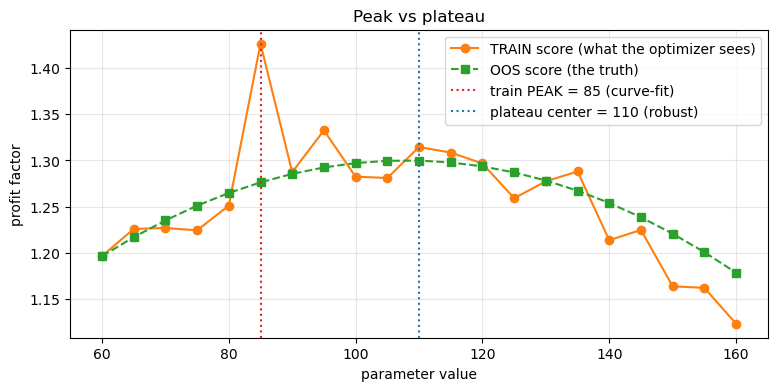

train picks 85 (the spike).  OOS truth favors the plateau around 110.
Shipping the train-peak = shipping noise. This is the 85x4 -> 108x4 story, in one chart.


In [2]:
# A stylized parameter sweep: train curve has a noisy SPIKE; the true (OOS) curve is a smooth plateau.
params = np.arange(60, 161, 5)                       # e.g. master-VP lookback candidates
rng = np.random.default_rng(7)
true_oos = 1.30 - 0.000045 * (params - 108)**2       # smooth plateau centered ~108
train = true_oos + rng.normal(0, 0.03, size=len(params))
train[params == 85] += 0.18                           # the seductive in-sample spike

peak_param = params[np.argmax(train)]
plateau_param = params[np.argmax(true_oos)]
fig, ax = plt.subplots()
ax.plot(params, train, "o-", label="TRAIN score (what the optimizer sees)", color="tab:orange")
ax.plot(params, true_oos, "s--", label="OOS score (the truth)", color="tab:green")
ax.axvline(peak_param, color="tab:red", ls=":", label=f"train PEAK = {peak_param} (curve-fit)")
ax.axvline(plateau_param, color="tab:blue", ls=":", label=f"plateau center = {plateau_param} (robust)")
ax.set_xlabel("parameter value"); ax.set_ylabel("profit factor"); ax.legend(); ax.set_title("Peak vs plateau")
plt.show()
print(f"train picks {peak_param} (the spike).  OOS truth favors the plateau around {plateau_param}.")
print("Shipping the train-peak = shipping noise. This is the 85x4 -> 108x4 story, in one chart.")

> 🧠 **The rule.** Accept a parameter only where the **sensitivity heatmap is stable** — neighbors are all
> good. A lone tall bar surrounded by bad ones is overfitting wearing a nice number. (This is also why NB 10's
> walk-forward exists: it's the automated version of "don't trust one window.")

## Step 2 · Walk-forward on the REAL locked stream

Now the real thing. The locked KK-MasterVP M5 config was replayed **continuously** over a full year
(2025-06 → 2026-05) — a single compounding account, no artificial train/OOS reset. That trade stream is in
the repo. We partition it into **calendar-month folds** and ask: *is the edge present in most months, or
carried by one lucky stretch?*

> 📘 **Concept — profit factor (PF).** `PF = gross profit / gross loss`. PF > 1 = the fold made money; PF < 1
> = it lost. A robust edge is **consistently** > 1 across folds, not a huge PF in one month dragging up a
> bunch of losers.

In [3]:
stream = PARITY / "_wf_fullrun.csv"
if stream.exists():
    s = pd.read_csv(stream)
    s["t"] = pd.to_datetime(s["entryTimeUTC"], format="%Y.%m.%d %H:%M")
    s["month"] = s["t"].dt.to_period("M")
    print(f"locked continuous stream: {len(s):,} trades, {s['t'].min().date()} -> {s['t'].max().date()}")
    print(f"total realized: ${s['realizedUsd'].sum():,.0f}   win-rate: {(s['realizedUsd']>0).mean():.1%}")

    def fold_stats(g):
        wins = g.loc[g["realizedUsd"] > 0, "realizedUsd"].sum()
        loss = -g.loc[g["realizedUsd"] < 0, "realizedUsd"].sum()
        pf = wins / loss if loss > 0 else np.inf
        return pd.Series({"n": len(g), "win%": (g["realizedUsd"] > 0).mean() * 100,
                          "PF": pf, "net$": g["realizedUsd"].sum()})
    by_month = s.groupby("month").apply(fold_stats)
    pos = (by_month["PF"] > 1).sum()
    print(f"\nWALK-FORWARD by month: {pos}/{len(by_month)} folds PF>1   (median PF {by_month['PF'].median():.3f})")
    display(by_month.round(3))
else:
    print("(_wf_fullrun.csv not present — run the WF harness: research/mastervp_parity/wf_mc.py)"); s = None

locked continuous stream: 1,413 trades, 2025-06-19 -> 2026-05-29
total realized: $31,108   win-rate: 58.0%

WALK-FORWARD by month: 11/12 folds PF>1   (median PF 1.281)


,n,win%,PF,net$
month,,,,
2025-06,48,60.417,1.413,803.99
2025-07,131,62.595,1.3,"1,814.76"
2025-08,138,47.101,0.68,"-2,721.1"
2025-09,128,64.844,1.709,"3,683.06"
2025-10,148,57.432,1.262,"2,566.74"
2025-11,122,59.016,1.063,535.21
2025-12,125,56.8,1.21,"1,970.02"
2026-01,132,56.818,1.369,"4,100.89"
2026-02,112,56.25,1.087,985.43


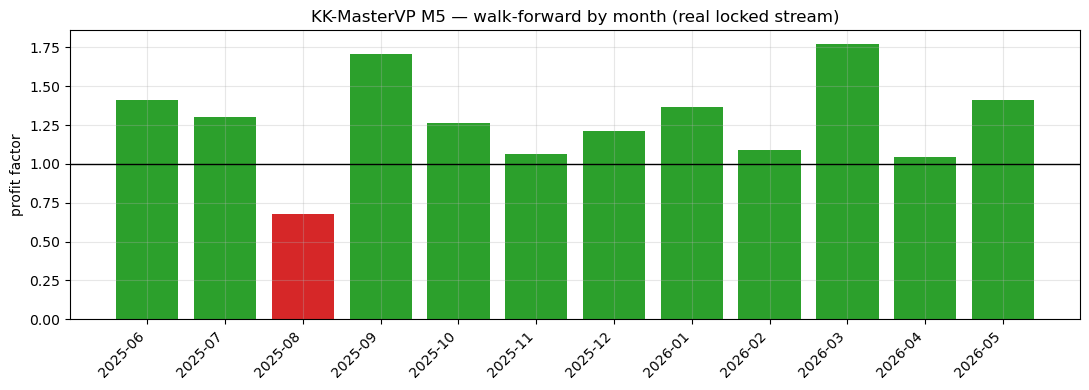

Weakest month: 2025-08  PF=0.680  net=$-2721
That single red month (trendless chop) is the breakout edge's known stress regime — not a bug,
a property. A robust edge is allowed losing months; it is NOT allowed to depend on one winning month.


In [4]:
# Visualize it: a green/red bar per month makes 'broad-based vs carried-by-one-period' obvious at a glance.
if s is not None:
    fig, ax = plt.subplots(figsize=(11, 4))
    colors = ["tab:green" if pf > 1 else "tab:red" for pf in by_month["PF"]]
    ax.bar([str(m) for m in by_month.index], by_month["PF"], color=colors)
    ax.axhline(1.0, color="k", lw=1)
    ax.set_ylabel("profit factor"); ax.set_title("KK-MasterVP M5 — walk-forward by month (real locked stream)")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()
    worst = by_month["PF"].idxmin()
    print(f"Weakest month: {worst}  PF={by_month.loc[worst,'PF']:.3f}  net=${by_month.loc[worst,'net$']:.0f}")
    print("That single red month (trendless chop) is the breakout edge's known stress regime — not a bug,")
    print("a property. A robust edge is allowed losing months; it is NOT allowed to depend on one winning month.")

## Step 3 · Monte-Carlo — luck or structure?

Walk-forward answers *"does the edge hold across time?"* Monte-Carlo answers *"how much of my result was the
particular sequence of trades I happened to get?"* We **de-compound** each trade to a return fraction (so
1%-fixed-fractional sizing makes returns stationary), then **bootstrap**: resample the trades with
replacement thousands of times and look at the distribution of outcomes.

> 📘 **Concept — bootstrap vs shuffle.** *Bootstrap* (resample **with replacement**) asks "what if the trade
> *mix* had been different?" — it stresses the edge itself. *Order-shuffle* (same trades, permuted) asks
> "what if they'd arrived in a different *order*?" — it stresses path/sequence risk (drawdown). We do both.

In [5]:
if s is not None:
    START = 10000.0
    # de-compound: approximate balance-before each trade under 1% fixed-fractional, then r_i = pnl/bal.
    # (The production tool tracks exact balance-before; this gives the same distributional picture.)
    bal = START + s["realizedUsd"].cumsum().shift(1).fillna(0.0)
    r = (s["realizedUsd"] / bal).values
    r = r[np.isfinite(r)]
    n = len(r)

    def equity_path(returns):
        eq = START * np.cumprod(1.0 + returns)
        peak = np.maximum.accumulate(eq)
        maxdd = ((peak - eq) / peak).max() * 100
        gains = returns[returns > 0].sum(); losses = -returns[returns < 0].sum()
        pf = gains / losses if losses > 0 else np.inf
        return eq[-1] / START, maxdd, pf

    rng = np.random.default_rng(12345)
    ITERS = 5000
    mult, dd, pf = np.empty(ITERS), np.empty(ITERS), np.empty(ITERS)
    for i in range(ITERS):
        samp = r[rng.integers(0, n, size=n)]      # bootstrap: resample WITH replacement
        mult[i], dd[i], pf[i] = equity_path(samp)
    print(f"Bootstrap Monte-Carlo on {n:,} real trades x {ITERS:,} iters\n")
    print(f"P(profit)            : {(mult > 1).mean():.1%}")
    print(f"PF   5th / 50th / 95th: {np.percentile(pf,5):.3f} / {np.percentile(pf,50):.3f} / {np.percentile(pf,95):.3f}")
    print(f"net% 5th / 50th / 95th: {(np.percentile(mult,5)-1)*100:+.0f}% / {(np.percentile(mult,50)-1)*100:+.0f}% / {(np.percentile(mult,95)-1)*100:+.0f}%")
    print(f"maxDD 50th / 95th / 99th: {np.percentile(dd,50):.1f}% / {np.percentile(dd,95):.1f}% / {np.percentile(dd,99):.1f}%")
    print(f"risk-of-ruin (equity ever <= 50% of start): {(dd >= 50).mean():.2%}")

Bootstrap Monte-Carlo on 1,413 real trades x 5,000 iters

P(profit)            : 99.6%
PF   5th / 50th / 95th: 1.101 / 1.255 / 1.423
net% 5th / 50th / 95th: +64% / +300% / +898%
maxDD 50th / 95th / 99th: 24.7% / 38.7% / 46.7%
risk-of-ruin (equity ever <= 50% of start): 0.54%


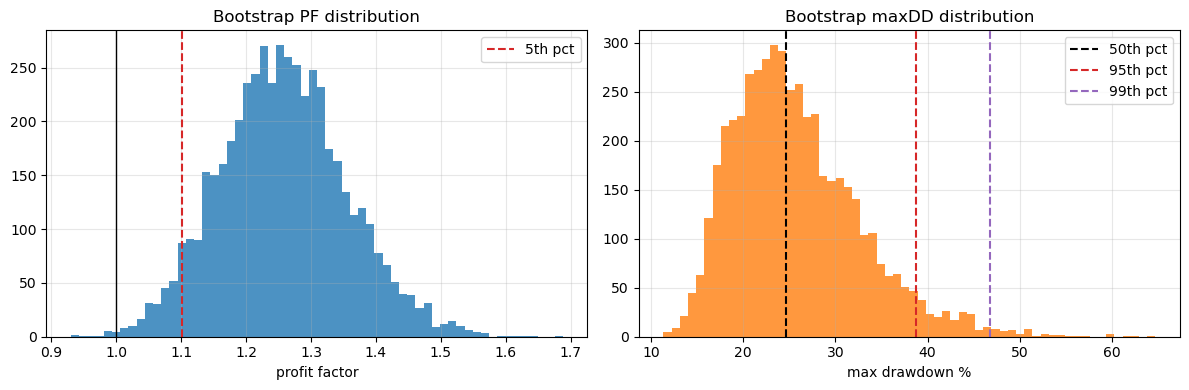

PF 5th-pctile > 1 = the edge survives resampling. The DD tail is the real story -> Step 4.


In [6]:
if s is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.hist(pf, bins=60, color="tab:blue", alpha=0.8)
    ax1.axvline(1.0, color="k", lw=1); ax1.axvline(np.percentile(pf,5), color="tab:red", ls="--", label="5th pct")
    ax1.set_title("Bootstrap PF distribution"); ax1.set_xlabel("profit factor"); ax1.legend()
    ax2.hist(dd, bins=60, color="tab:orange", alpha=0.8)
    for q, c in [(50, "k"), (95, "tab:red"), (99, "tab:purple")]:
        ax2.axvline(np.percentile(dd, q), color=c, ls="--", label=f"{q}th pct")
    ax2.set_title("Bootstrap maxDD distribution"); ax2.set_xlabel("max drawdown %"); ax2.legend()
    plt.tight_layout(); plt.show()
    print("PF 5th-pctile > 1 = the edge survives resampling. The DD tail is the real story -> Step 4.")

## Step 4 · Drawdown honesty — the number that lied

Here is the most expensive lesson in the whole project, and it cost *zero* code to fix — only honesty.

> 🧨 **The real case.** The shipped headline was **"OOS drawdown ~10.3%,"** measured on a benign 4-month
> split window. Replayed over a **full year**, the *same config* draws down **27.7%**, and Monte-Carlo puts
> the 95th percentile near **38%** and the order-shuffle worst case at **~55%**. Nothing changed but the
> window. Size for ~30–40% peak-to-trough, **not** 10%.

The trap is that *you can always find a calm window if you go looking*. To prove it honestly, we don't
hardcode a flattering slice — we **search every 4-month window** and report the calmest one, against the
full year. Drawdown is measured on the **de-compounded** (1%-fixed-fractional) basis from Step 3, which is
the sizing-relevant number and how the headline was originally computed.

> ⚠️ **Why de-compounded, not raw $.** On a compounding account, a late-period dip is a huge *dollar* swing
> simply because the balance is large by then — which inflates raw-$ drawdown and muddies the comparison. The
> fixed-fractional return series makes windows comparable and matches what position-sizing actually keys off.

CALMEST 4-month window  2026-02..2026-05 : 13.9%   <- the seductive headline
FULL YEAR (same config)                  : 27.7%   <- the honest number
Monte-Carlo 95th-pctile maxDD            : 38.7%   <- what to size for

=> the same locked config looks 2.0x calmer if you quote the right 4 months.


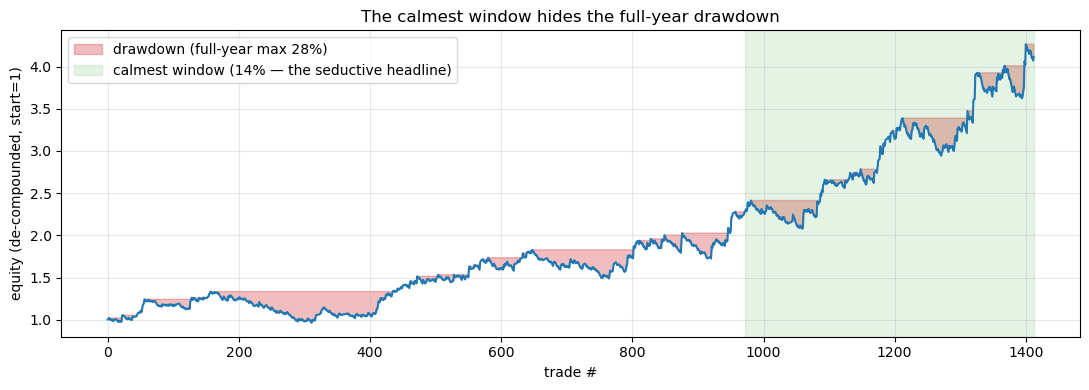

In [7]:
if s is not None:
    # de-compounded return series (same basis as Step 3)
    bal_all = START + s["realizedUsd"].cumsum().shift(1).fillna(0.0)
    s = s.assign(r=(s["realizedUsd"] / bal_all))

    def dd_frac(returns):
        eq = np.cumprod(1.0 + np.asarray(returns))
        peak = np.maximum.accumulate(eq)
        return ((peak - eq) / peak).max() * 100, eq

    full_dd, eq_full = dd_frac(s["r"].values)

    # search EVERY rolling 4-calendar-month window; the calmest is the one a cherry-picker would quote.
    months = sorted(s["t"].dt.to_period("M").unique())
    wins = []
    for i in range(len(months) - 3):
        sel = months[i:i+4]
        g = s[s["t"].dt.to_period("M").isin(sel)]
        wins.append((sel[0], sel[-1], dd_frac(g["r"].values)[0]))
    calm = min(wins, key=lambda w: w[2])

    print(f"CALMEST 4-month window  {calm[0]}..{calm[1]} : {calm[2]:.1f}%   <- the seductive headline")
    print(f"FULL YEAR (same config)                  : {full_dd:.1f}%   <- the honest number")
    print(f"Monte-Carlo 95th-pctile maxDD            : {np.percentile(dd,95):.1f}%   <- what to size for")
    print(f"\n=> the same locked config looks {full_dd/calm[2]:.1f}x calmer if you quote the right 4 months.")

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(range(len(eq_full)), eq_full, color="tab:blue")
    peak = np.maximum.accumulate(eq_full)
    ax.fill_between(range(len(eq_full)), eq_full, peak, where=eq_full < peak, color="tab:red",
                    alpha=0.3, label=f"drawdown (full-year max {full_dd:.0f}%)")
    # shade the calm window by trade-index span
    cmask = s["t"].dt.to_period("M").isin(pd.period_range(calm[0], calm[1], freq="M")).values
    idx = np.where(cmask)[0]
    ax.axvspan(idx.min(), idx.max(), color="tab:green", alpha=0.12,
               label=f"calmest window ({calm[2]:.0f}% — the seductive headline)")
    ax.set_xlabel("trade #"); ax.set_ylabel("equity (de-compounded, start=1)")
    ax.set_title("The calmest window hides the full-year drawdown"); ax.legend()
    plt.tight_layout(); plt.show()

> 🧠 **The discipline.** Report the drawdown of the **worst plausible path**, not the one you backtested:
> the full-period realized DD, *and* the Monte-Carlo 95th-percentile, *and* the shuffle worst case. Position
> sizing keys off the number you're willing to be wrong about — and the benign-window number will get you
> margin-called in the month it doesn't hold. Risk-of-ruin stayed negligible here at 1%/trade, but the lived
> experience includes 25%+ dips, and the trader has to *know that going in*.

## Step 5 · The clinching test — fixed beats per-fold re-optimization

The gold-standard overfitting check: at each step, **re-select** the parameter on an expanding in-sample,
then trade it untouched on the next out-of-sample fold. Two things must be true for a config to be trusted:

1. The optimizer must keep picking **inside the known plateau** (never chasing an extreme). On KK-MasterVP it
   always picked `480/432/576` bars — squarely in the `384–480` plateau. The selection process isn't fitting noise.
2. **Walk-forward efficiency ≈ 1.0** — out-of-sample PF ≈ in-sample PF, i.e. no degradation when the params
   meet unseen data.

> 🏆 **The decisive result.** The **fixed** locked-`432` beat the per-fold re-optimizer on the same folds
> (5/5 vs 4/5 folds PF>1; mean PF **1.282 vs 1.206**). Re-tuning every fold *did not help*. That's the signature
> of a real plateau, not a curve-fit: the single fixed value generalizes as well as — or better than — constantly
> re-adapting. (Full table in `research/mastervp_parity/WF_MC_FINDINGS.md`.)

> ⚠️ **The counter-intuition for engineers.** More adaptation is not more robustness. A model that must be
> re-tuned every period to stay good is telling you its edge is fragile. The lock needs no periodic re-tuning —
> which is exactly why it's safe to ship.

## 🎯 Recap & your turn

**What you learned**
1. **Peak vs plateau** — the train-best parameter is usually noise; ship the center of a stable region. (The
   real `85→108` length and `4.0→2.5` trail catches.)
2. **Walk-forward on real trades** — the locked stream is positive in 11/12 months; the one red month is a
   known regime, not a flaw. An edge may lose months; it may not depend on one winning month.
3. **Monte-Carlo** — bootstrap the real returns: P(profit) ~99%+, PF 5th-pctile > 1, ruin negligible — but
   the **DD tail is wide**.
4. **Drawdown honesty** — the same config is ~10% DD on a calm window and ~28% over the year (95th ~38%).
   Headline the worst plausible path; size for it.
5. **Fixed-beats-reopt** — a config that needs constant re-tuning is fragile; a real plateau generalizes
   fixed.

> 🔑 NB 11 made the backtest *true*; NB 12 made it *honest*. Together they're the difference between "the
> engine liked it" and "cleared for forward-test."

**🎯 Your turn**
1. **Equal-N folds.** Re-do Step 2 splitting the stream into 8 equal-trade-count folds instead of calendar
   months. Do you still get ~7/8 positive? Which framing (time vs trade-count) is fairer, and why?
2. **Add the order-shuffle.** In Step 3, add a loop that keeps the same `r` but **permutes** it each iter
   (`rng.permutation(r)`) and collect maxDD. Compare its 95th-pctile to the bootstrap's. Which is the more
   conservative DD to size from?
3. **Stress the sizing.** Re-run Step 4's equity curve at 2% risk (scale `realizedUsd` by 2). Where does the
   full-year DD land, and would risk-of-ruin still be negligible?
4. **Read the source of truth.** Open `research/mastervp_parity/WF_MC_FINDINGS.md` and `wf_mc.py`. Find the
   anchored re-opt table and confirm the "fixed beats re-opt" claim against the per-fold numbers.

> ➡️ **You've finished the reliability half of the track.** NB 00–10 find an edge; NB 11–12 prove it's real
> and honest. Together they're the full arc from "raw broker text" to "an EA you'd actually run."